In [1]:
import pandas as pd

#데이터 준비: 입력/타깃, 훈련/테스트, 전처리/표준화
fish = pd.read_csv(r'https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv', low_memory=False)
fish.head()
print(fish.columns)
fish_input = fish.iloc[:, 1:6]
fish_target = fish['Species']

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

Index(['Species', 'Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='object')


In [3]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

print(train_input.columns)
print(kn.classes_)
print(kn.predict(test_scaled[:5]))
print(np.round(kn.predict_proba(test_scaled[:5]), decimals=4))
idxs = kn.kneighbors(test_scaled[3:4], return_distance=False)
print(train_target.iloc[idxs[0]])

0.8907563025210085
0.85
Index(['Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='object')
['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]
52     Roach
106    Perch
103    Perch
Name: Species, dtype: object


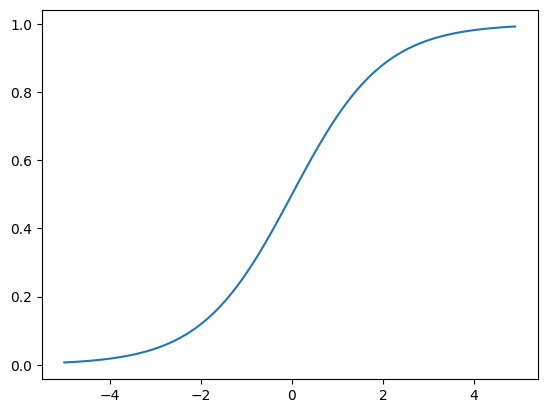

In [5]:
x = np.arange(-5, 5, 0.1)
import matplotlib.pyplot as plt
y = 1 / (1 + np.exp(-x))
plt.plot(x, y)
plt.show()

In [ ]:
#이진분류 로지스틱 회귀

#불리언 인덱스로 이진 분류 데이터 만들기
bream_smelt_idxs = (train_target == 'Bream') | (train_target == 'Smelt')
bream_smelt_idxs
train_bs_input = train_scaled[bream_smelt_idxs]
train_bs_target = train_target[bream_smelt_idxs]
train_bs_target = (train_bs_target == 'Bream')

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bs_input, train_bs_target)
print(lr.predict(train_bs_input[:5]))
print(lr.predict_proba(train_bs_input[:5]))
print(lr.classes_)
print(lr.coef_, lr.intercept_)
z = lr.decision_function(train_bs_input[:5])

from scipy.special import expit
print(expit(z))

[1 0 1 1 1]
[[0.00239993 0.99760007]
 [0.97262675 0.02737325]
 [0.00513614 0.99486386]
 [0.01414953 0.98585047]
 [0.00232581 0.99767419]]
[0 1]
[[0.40451732 0.57582787 0.66248158 1.01329614 0.73123131]] [2.16172774]
[0.99760007 0.02737325 0.99486386 0.98585047 0.99767419]


In [ ]:
#다중분류 로지스틱회귀분석
lr2 = LogisticRegression(C=20, max_iter=1000)
lr2.fit(train_scaled, train_target)
print(lr2.score(train_scaled, train_target))
print(lr2.score(test_scaled, test_target))
print(lr2.predict(test_scaled[:5]))
prob = lr2.predict_proba(test_scaled[:5])
print(lr2.classes_)
print(np.round(prob, decimals=3))
print()
print(lr2.coef_, lr2.intercept_)

from scipy.special import softmax
z2 = lr2.decision_function(test_scaled[:5])
print(np.round(z2, decimals=2))
prob2 = softmax(z2, axis=1)
print(np.round(prob2, decimals=3))
print(np.round(prob, decimals=3) == np.round(prob2, decimals=3))


0.9327731092436975
0.925
['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']
['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]

[[-1.50605455 -1.03747913  2.60919713  7.69422739 -1.18603342]
 [ 0.19200047 -1.99988812 -3.79617725  6.50312639 -2.00022754]
 [ 3.55793539  6.36988929 -8.52233732 -5.75397233  3.79233438]
 [-0.11453308  3.61060121  3.94464503 -3.62243904 -1.75981679]
 [-1.40843717 -6.09242191  5.28629633 -0.86696569  1.84518455]
 [-1.33419951  1.48153392  1.38217547 -5.6602348  -4.39228963]
 [ 0.61328846 -2.33223527 -0.90379939  1.70625807  3.70084846]] [-0.10345046 -0.27281217  3.24444852 -0.17565069  2.64960025 -6.72042852
  1.37829306]
[[ -6.51   1.04   5.17  -2.76   3.34   0.35  -0.63]
 [-10.88   1.94   4.78  -2.42   2.99   7.84  -4.25]
 [ -4.34  -6